# Multi-Agent Recommender System: Concepts & Architecture

This notebook provides a pedagogical explanation of the core components of the project:
1. **Data & Simulations**: How real-world data feeds into the simulation environment.
2. **Experiment Protocols**: The standardized ways we test our hypotheses.
3. **Markov Chain Analysis**: How we analyze the long-term behavior of the system.


## 1. Connecting Simulations and Data

In this project, we bridge the gap between static datasets (like MovieLens) and dynamic Reinforcement Learning (RL) simulations using **Adapters**.

### The Concept
A typical RL simulation needs an **Environment** that provides rewards. Instead of using a purely synthetic environment, we create a **Reward Landscape** derived from real data.

*   **X-Axis (Contexts)**: We cluster users into groups based on their behavior (e.g., genre preferences). Each cluster becomes a "Context".
*   **Y-Axis (Recommendations)**: We select the top-N most popular items (e.g., movies). These are the actions available to the Recommender.
*   **Z-Axis (Reward)**: The average rating given by users in a specific cluster to a specific item becomes the expected reward.

### Visualization
The code below generates a synthetic "Reward Landscape" to illustrate what the `MovieLensEnvironmentAdapter` constructs.

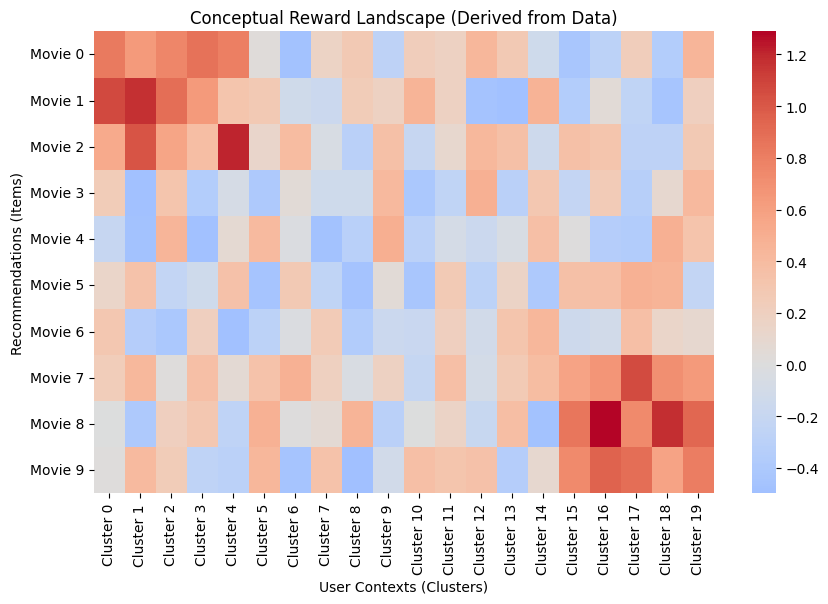

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate a Reward Landscape associated with MovieLensAdapter
n_contexts = 20  # User Clusters (e.g., "Action Lovers", "Romance Fans")
n_items = 10     # Top Movies

# Create a synthetic landscape
# Represents average ratings (normalized to -1 to 1 for the simulation)
landscape = np.random.uniform(-0.5, 0.5, (n_items, n_contexts))

# Add some structure (Action lovers like Action movies)
# Context 0-5 (Action Fans) like Items 0-3 (Action Movies)
landscape[0:3, 0:5] += 0.8

# Context 15-20 (Romance Fans) like Items 7-10 (Romance Movies)
landscape[7:10, 15:20] += 0.8

plt.figure(figsize=(10, 6))
sns.heatmap(landscape, cmap="coolwarm", center=0, 
            xticklabels=[f"Cluster {i}" for i in range(n_contexts)],
            yticklabels=[f"Movie {i}" for i in range(n_items)])
plt.title("Conceptual Reward Landscape (Derived from Data)")
plt.xlabel("User Contexts (Clusters)")
plt.ylabel("Recommendations (Items)")
plt.show()

## 2. Experiment Protocols

To ensure scientific rigor, we defined three standard protocols in `src/experiments/protocols.py`. Each protocol tests a specific aspect of the User-Recommender interaction.

| Protocol | Name | Description | Key Metric |
| :--- | :--- | :--- | :--- |
| **A** | **Stationary Baseline** | Standard RL setup. No psychological modulation. Fixed environment. | **Convergence Time**: How fast does the agent find the optimal items? |
| **B** | **Modulated Learning** | Initializes psychological modulators (e.g., Boredom). The user's reward perception changes based heavily on history. | **Suboptimality Gap**: Does the user get "stuck" accepting worse items because of their internal state? |
| **C** | **Non-Stationary** | The environment itself changes over time (e.g., user preferences drift naturally). | **Tracking Error**: Can the recommender keep up with the changing user? |

### Example Configuration
Here is how these protocols are configured in code:

In [2]:
from dataclasses import dataclass

# Simplified representation of the Protocol Config structure
@dataclass
class ProtocolConfig:
    name: str
    modulator_active: bool
    environment_static: bool

protocols = {
    "A": ProtocolConfig("Stationary", modulator_active=False, environment_static=True),
    "B": ProtocolConfig("Modulated", modulator_active=True, environment_static=True),
    "C": ProtocolConfig("Non-Stationary", modulator_active=False, environment_static=False)
}

for key, p in protocols.items():
    print(f"Protocol {key}: {p.name} -> Modulator: {p.modulator_active}, Static Env: {p.environment_static}")

Protocol A: Stationary -> Modulator: False, Static Env: True
Protocol B: Modulated -> Modulator: True, Static Env: True
Protocol C: Non-Stationary -> Modulator: False, Static Env: False


## 3. Markov Chain Analysis

We model the entire interaction as a **Markov Chain**. 

### What is the "State"?
The state of the system is complex. It represents the combination of:
1.  **User's Beliefs**:Represented by their Q-values (what they think is good).
2.  **Recommender's Beliefs**: Represented by their Q-values (what they think the user likes).
3.  **Modulator State**: E.g., current "boredom" level.
4.  **Context**: The current user cluster active in the environment.

### Why Markov Chains?
By treating simulations as trajectories through this state space, we can mathematically analyze:
*   **Absorption**: Does the system settle into a permanent loop (e.g., Filter Bubble)?
*   **Mixing Time**: How long generally does it take to stabilize?
*   **Ergodicity**: Can the system reach any state from any other state, or are some regions "walled off"?

### Visualization: Convergence Trajectory
We track the "distance" between states over time. As the agents learn, the system state should change less and less, eventually approaching zero (Absorption).

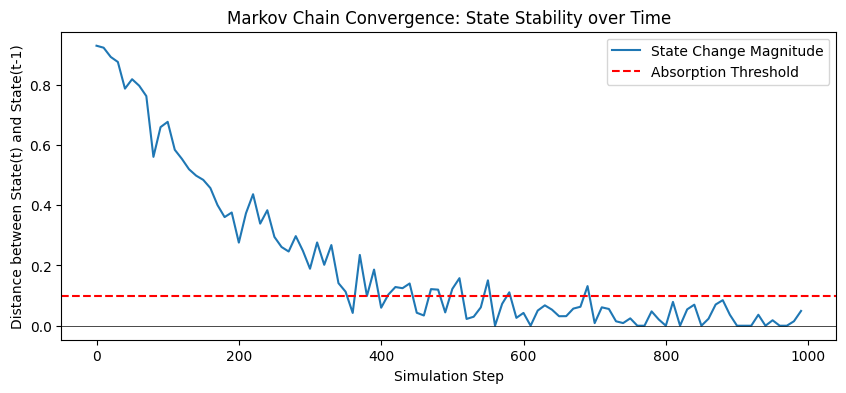

In [3]:
import matplotlib.pyplot as plt

# Simulated convergence data
steps = np.arange(0, 1000, 10)
# Distance between consecutive states decreases as agents learn
state_deltas = np.exp(-steps / 200) + np.random.normal(0, 0.05, len(steps))
state_deltas = np.clip(state_deltas, 0, None)

plt.figure(figsize=(10, 4))
plt.plot(steps, state_deltas, label="State Change Magnitude")
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(0.1, color='red', linestyle='--', label="Absorption Threshold")
plt.title("Markov Chain Convergence: State Stability over Time")
plt.xlabel("Simulation Step")
plt.ylabel("Distance between State(t) and State(t-1)")
plt.legend()
plt.show()